## 0. 教程大纲

### 0.1 卷积
```python
cv.filter2D(img, -1, kernel)
```

### 0.2 均值模糊
```python
cv.blur(img, (5,5))
cv.boxFilter(img, -1, (5,5))
```

### 0.3 中值滤波
```python
cv.medianBlur(img, 3)
```

### 0.4 高斯模板
```python
cv.GaussianBlur(img, (5,5), sigma)
```

### 0.5 双边滤波
```python
cv.bilateralFilter(img, -1, sigmaColor=50, sigmaSpace=3)
```

In [ ]:
import cv2 as cv              # OpenCV计算机视觉库
import numpy as np            # NumPy数值计算库
import matplotlib.pyplot as plt  # Matplotlib绑图库

In [ ]:
def show(img):
    """自定义显示函数：自动判断灰度图或彩色图并正确显示"""
    if img.ndim == 2:  # 灰度图
        plt.imshow(img, cmap='gray')
    else:  # 彩色图，BGR转RGB
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        plt.imshow(img)
    plt.show()

## * 二维高斯分布

$$
G(x,y,\sigma) = \frac{1}{2\pi\sigma^2}e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$

In [ ]:
# 可视化二维高斯分布的3D曲面图
# sigma=50控制高斯核的宽度，值越大核越宽、模糊效果越强
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

sigma = 50
x, y = np.mgrid[-100:100:1, -100:100:1]  # 生成网格坐标

# 高斯函数：G(x,y) = 1/(2*pi*sigma^2) * exp(-(x^2+y^2)/(2*sigma^2))
z = 1/(2 * np.pi * (sigma**2)) * np.exp(-(x**2+y**2)/(2 * sigma**2))

fig = plt.figure()
ax = Axes3D(fig)
ax.plot_surface(x, y, z, rstride=1, cstride=1, cmap='jet', alpha=0.8)
plt.show()

## 4 模糊化

In [ ]:
# 读取灰度图用于各种滤波方法演示
img = cv.imread('pic/rose200x200.jpg', 0)
show(img)

### 4.1 自定义滤波器

In [ ]:
# cv.filter2D()：自定义卷积核滤波
# 创建5x5均值滤波核：全1矩阵除以25（归一化，使像素总和为1）
kernel = np.ones((5, 5), dtype=np.float32)
kernel /= kernel.sum()  # 归一化

img_filter = cv.filter2D(img, -1, kernel)  # -1表示输出与输入深度相同
show(np.hstack([img, img_filter]))

### 4.2 均值模糊

In [ ]:
# cv.blur()：均值模糊，用邻域像素的平均值替代中心像素
img_mblur = cv.blur(img, (5, 5))  # 5x5核的均值模糊
show(np.hstack([img, img_mblur]))

In [ ]:
# 用均值模糊处理高斯噪声图：效果一般（均值模糊对高斯噪声有一定效果）
img_gnoise = cv.imread('pic/rose_gaussiannoise_200x200.jpg', 0)
img_mblur = cv.blur(img_gnoise, (5, 5))
show(np.hstack([img, img_gnoise, img_mblur]))  # 原图 | 高斯噪声 | 均值模糊

In [10]:
cv.imwrite("pic/rose_remove_gnoise.jpg", np.hstack([img, img_gnoise, img_mblur]))

True

In [ ]:
# 用均值模糊处理椒盐噪声图：效果较差（椒盐噪声的极端值拉偏了平均值）
img_spnoise = cv.imread('pic/rose_spnoise_200x200.jpg', 0)
img_mblur = cv.blur(img_spnoise, (5, 5))
show(np.hstack([img, img_spnoise, img_mblur]))  # 原图 | 椒盐噪声 | 均值模糊

In [12]:
cv.imwrite("pic/rose_remove_spnoise.jpg", np.hstack([img, img_spnoise, img_mblur]))

True

### 4.3 Gaussian模糊

In [ ]:
# cv.GaussianBlur()：高斯模糊，sigma越小越轻度模糊，sigma越大越强模糊
img_gblur1 = cv.GaussianBlur(img_spnoise, (5, 5), 0.5)  # sigma=0.5，轻度模糊
img_gblur2 = cv.GaussianBlur(img_spnoise, (5, 5), 10)   # sigma=10，强模糊
show(np.hstack([img_spnoise, img_gblur1]))  # 椒盐噪声 vs sigma=0.5
show(np.hstack([img_spnoise, img_gblur2]))  # 椒盐噪声 vs sigma=10

### 4.4 中值模糊

In [ ]:
# cv.medianBlur()：中值滤波，取邻域像素的中值，对椒盐噪声效果最好
img_blur1 = cv.medianBlur(img_gnoise, 3)   # 对高斯噪声用中值滤波
img_blur2 = cv.medianBlur(img_spnoise, 3)  # 对椒盐噪声用中值滤波（效果最佳）
show(np.hstack([img_gnoise, img_blur1]))    # 高斯噪声 vs 中值滤波
show(np.hstack([img_spnoise, img_blur2]))   # 椒盐噪声 vs 中值滤波

In [15]:
cv.imwrite("pic/rose_gnoise_median.jpg", np.hstack([img, img_gnoise, img_blur1]))
cv.imwrite("pic/rose_spnoise_median.jpg", np.hstack([img, img_spnoise, img_blur2]))

True

## 附：添加噪声

In [ ]:
#### 1. 椒盐噪声生成函数
def salt_pepper_noise(img, ratio=0.02):
    """生成椒盐噪声：随机将ratio比例的像素设为随机低值"""
    img = img.copy()
    for _ in range(int(img.size * ratio)):
        i = np.random.randint(0, img.shape[0])
        j = np.random.randint(0, img.shape[1])
        img[i, j] = np.random.randint(0, 100)
    print(img.min())
    return img

img = cv.imread('pic/rose200x200.jpg', 0)
img_sp = salt_pepper_noise(img)
show(np.hstack([img, img_sp]))  # 原图 vs 椒盐噪声

In [18]:
cv.imwrite('pic/rose_spnoise_200x200.jpg', img_sp)

True

In [ ]:
def gaussian_noise(img, mean=0, var=20):
    """生成高斯噪声：添加均值为mean、方差为var的正态分布噪声"""
    noise = np.random.normal(mean, var, img.shape)
    img = img.astype(np.float) + noise  # 图像转为浮点后叠加噪声
    return img

In [ ]:
# 生成高斯噪声并显示对比
img = cv.imread('pic/rose200x200.jpg', 0)
img_ga = gaussian_noise(img)
show(np.hstack([img, img_ga]))  # 原图 vs 高斯噪声

In [ ]:
# cv.bilateralFilter()：双边滤波，在平滑噪声的同时保留边缘细节
# 参数：(图像, 直径d, 颜色空间sigmaColor, 坐标空间sigmaSpace)
img = cv.imread('pic/beer.jpg')
show(img)

img2 = cv.bilateralFilter(img, 11, sigmaColor=50, sigmaSpace=3)
show(img2)

### 双边滤波实现

In [ ]:
# 手动实现双边滤波的两个核心函数
def get_c(sigmad, n):
    """空间距离权重C：根据像素与中心的空间距离计算高斯权重"""
    C = np.zeros((n, n))
    center = np.array([n//2, n//2])
    for i in range(n):
        for j in range(n):
            cur = np.array([i, j])
            C[i, j] = np.exp(-0.5 * (np.linalg.norm(cur - center)/sigmad)**2)
    C /= C.sum()
    return C

def get_s(part, sigmar, n):
    """颜色相似度权重S：根据像素与中心的亮度差异计算高斯权重"""
    part = np.float64(part)
    S = np.exp(-0.5 * ((part - part[n//2, n//2])/sigmar)**2)
    S /= S.sum()
    return S

In [ ]:
%%time

# 手动实现双边滤波：综合空间权重C和颜色权重S
img = cv.imread('pic/beer.jpg', 0)
img2 = cv.bilateralFilter(img, 11, sigmaColor=50, sigmaSpace=3)  # OpenCV实现

sigmad = 3   # sigmaSpace：空间距离的标准差
sigmar = 50  # sigmaColor：颜色差异的标准差
n = 11       # 滤波核大小

h, w = img.shape
img3 = np.ones_like(img, dtype=np.float64)

C = get_c(sigmad, n)  # 预计算空间权重

# 遍历每个像素（跳过边界）
for i in range(n//2, h-n//2):
    for j in range(n//2, w-n//2):
        part = img[i-n//2:i-n//2+n, j-n//2:j-n//2+n]  # 取邻域
        S = get_s(part, sigmar, n)   # 计算颜色权重
        K = C * S                     # 综合权重 = 空间权重 * 颜色权重
        K /= K.sum()                  # 归一化
        img3[i, j] = (K * part).sum() # 加权求和

show(img3)

In [114]:
img3.dtype

dtype('float64')

In [ ]:
# 将float64结果转为uint8显示
show(img3.astype(np.uint8))

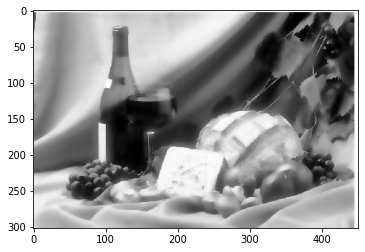

In [102]:
show(img2)

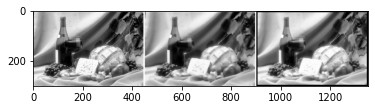

In [101]:
show(np.hstack([img, img2, img3]))

In [108]:
cv.imwrite('test/bilateral_filter.jpg', np.hstack([img, img2, img3]).astype(np.uint8))

True

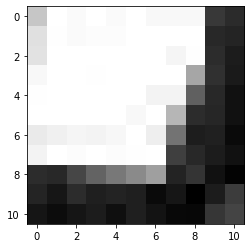

In [74]:
ss = 100
part = img[ss:ss+n, ss:ss+n]
show(part)

In [75]:
part

array([[222, 255, 252, 255, 252, 255, 251, 251, 251, 142, 134],
       [237, 254, 252, 253, 253, 255, 255, 255, 255, 132, 130],
       [238, 255, 255, 255, 255, 255, 255, 249, 254, 135, 125],
       [251, 255, 255, 254, 255, 255, 255, 255, 204, 137, 124],
       [254, 255, 255, 255, 255, 255, 248, 248, 164, 132, 119],
       [255, 255, 255, 255, 255, 251, 255, 213, 135, 131, 119],
       [243, 246, 249, 248, 250, 255, 245, 175, 126, 128, 115],
       [248, 255, 253, 255, 253, 254, 255, 145, 132, 125, 119],
       [135, 132, 149, 166, 178, 188, 200, 129, 139, 119, 111],
       [130, 122, 135, 127, 129, 127, 115, 122, 109, 125, 144],
       [121, 116, 121, 125, 118, 127, 120, 114, 113, 140, 148]],
      dtype=uint8)

In [76]:
part.astype(np.int) - part[5,5]

array([[ -29,    4,    1,    4,    1,    4,    0,    0,    0, -109, -117],
       [ -14,    3,    1,    2,    2,    4,    4,    4,    4, -119, -121],
       [ -13,    4,    4,    4,    4,    4,    4,   -2,    3, -116, -126],
       [   0,    4,    4,    3,    4,    4,    4,    4,  -47, -114, -127],
       [   3,    4,    4,    4,    4,    4,   -3,   -3,  -87, -119, -132],
       [   4,    4,    4,    4,    4,    0,    4,  -38, -116, -120, -132],
       [  -8,   -5,   -2,   -3,   -1,    4,   -6,  -76, -125, -123, -136],
       [  -3,    4,    2,    4,    2,    3,    4, -106, -119, -126, -132],
       [-116, -119, -102,  -85,  -73,  -63,  -51, -122, -112, -132, -140],
       [-121, -129, -116, -124, -122, -124, -136, -129, -142, -126, -107],
       [-130, -135, -130, -126, -133, -124, -131, -137, -138, -111, -103]])

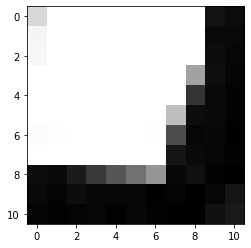

In [77]:
S = get_s(part, sigmar, n=11)
show(S)